# Investigations into the Grain Form of the Layer Above the Layer of Concern or Failure


### Grain Form of Layer Above the Layer of Concern in Pits Dug on Avalanche Crowns and Flanks

**Follow up question from Karl:**
- For all of the avalanches where the LOC is depth hoar, what crystal type is the layer immediately above the LOC? In other words, what percentage of those layers above the LOC are new snow, small facets, depth hoar, etc.?

In [51]:
# Imports and Constants

from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import pandas as pd
import seaborn as sns
import numpy as np

from caaml_utils import parse_caaml_directory

color_palette = {
    'crown_weak_layer': '#6F1D1B',
    'flank_weak_layer': '#C05746',
    'crown_above_weak_layer': '#014F86',
    'flank_above_weak_layer': '#61A5C2',
    'weak_layer': '#8C2D04',
    'layer_above_weak_layer': '#2A6F97',
}



In [14]:
# Parse all CAAML files in *data_dir* and return a list of Pit objects.

data_dir = '../snowpits/2015_2025'
if data_dir is None:
    raise FileNotFoundError('Could not find snowpits/2015_2025 from the current notebook working directory.')

all_pits = parse_caaml_directory(data_dir)

print(f'Loaded {len(all_pits):,} snow pits')

Loaded 50,278 snow pits


In [15]:
# helper function for distribution bar plots
def plot_grain_form_distribution(df, column, title, xlabel, *, hue=None, style_key=None):
    plot_df = df.copy()
    if column not in plot_df.columns:
        available_columns = ', '.join(map(str, plot_df.columns)) or '(no columns)'
        raise KeyError(f"Column '{column}' not found. Available columns: {available_columns}")
    plot_df[column] = plot_df[column].fillna('(no info)')
    order = plot_df[column].value_counts().index.tolist()
    plot_df[column] = pd.Categorical(plot_df[column], categories=order, ordered=True)
    bar_totals = plot_df.groupby(column, observed=False).size().reindex(order, fill_value=0)
    total_count = len(plot_df)

    fig, ax = plt.subplots(figsize=(10, 6))
    histplot_kwargs = {'data': plot_df, 'x': column, 'ax': ax}
    if hue is not None:
        histplot_kwargs['hue'] = hue
        histplot_kwargs['multiple'] = 'stack'
        hue_order = sorted(plot_df[hue].dropna().unique())
        if hue_order:
            histplot_kwargs['hue_order'] = hue_order
        if style_key == 'weak_layer':
            histplot_kwargs['palette'] = {
                'crown': color_palette['crown_weak_layer'],
                'flank': color_palette['flank_weak_layer'],
            }
        elif style_key == 'layer_above_weak_layer':
            histplot_kwargs['palette'] = {
                'crown': color_palette['crown_above_weak_layer'],
                'flank': color_palette['flank_above_weak_layer'],
            }
    elif style_key is not None:
        histplot_kwargs['color'] = color_palette[style_key]

    sns.histplot(**histplot_kwargs)

    if hue is not None:
        for i, value in enumerate(order):
            total = int(bar_totals.loc[value])
            if total <= 0:
                continue
            pct = 100 * total / total_count if total_count else 0
            ax.annotate(
                f'{total:,} ({pct:.1f}%)',
                xy=(i, total),
                xytext=(0, 4),
                textcoords='offset points',
                ha='center',
                fontsize=10,
            )
    elif ax.containers:
        container = ax.containers[0]
        max_h = max((patch.get_height() for patch in container.patches), default=0)
        ax.set_ylim(0, max_h * 1.32 if max_h > 0 else 1)

        labels = []
        for value in order:
            total = int(bar_totals.loc[value])
            pct = 100 * total / total_count if total_count else 0
            labels.append(f'{total:,}\n({pct:.1f}%)')
        ax.bar_label(container, labels=labels, padding=5, fontsize=10)
        ax.margins(x=0.02)

    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
    ax.set_title(f'{title} (n = {total_count:,})')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frequency')
    fig.tight_layout()
    plt.show()

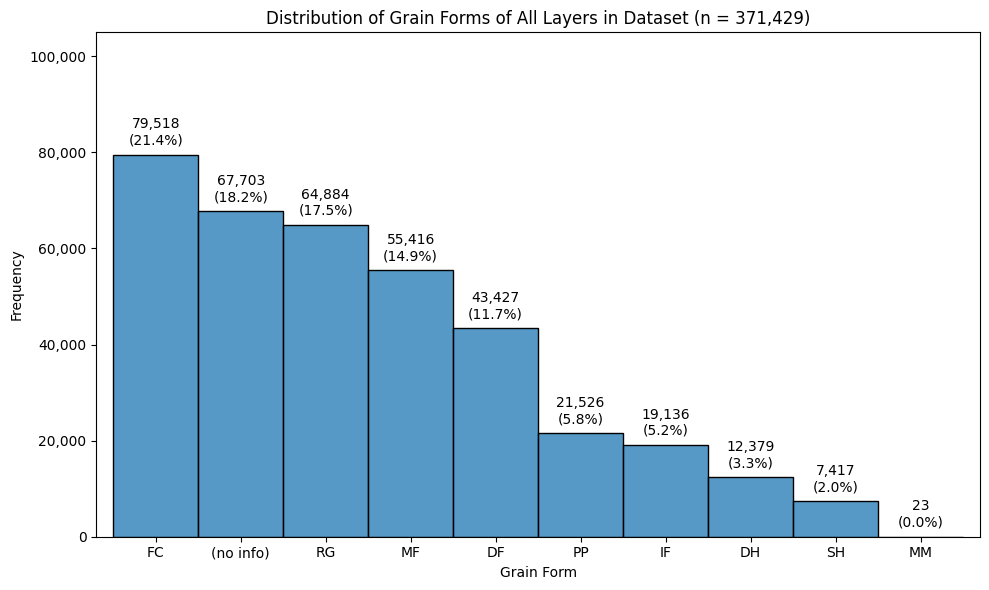

In [16]:
## Collect and plot grain form of all layers in dataset

# Collect grain form of all layers in dataset
grain_form_df = []

for pit in all_pits:
    for i, layer in enumerate(pit.snow_profile.layers):
        grain_form = getattr(layer, "grain_form_primary", None)
    
        grain_form_df.append({
            'pit_id': pit.core_info.pit_id,
            'layer_idx': i,
            'grain_form': getattr(grain_form, "basic_grain_class_code", None) if grain_form else None
        })

grain_form_df = pd.DataFrame(grain_form_df)

# Plot distribution of grain form of all layers in dataset
plot_grain_form_distribution(
    grain_form_df,
    'grain_form',
    'Distribution of Grain Forms of All Layers in Dataset',
    'Grain Form',
)


### Grain Form of Layer Above All Depth Hoar Layers in Dataset

For all depth hoar layers in the entire dataset, what is the distribution of grain forms directly above these depth hoar layers? (Note: DH layers at the top of the snowpack will have no layer above them and are recorded as "(no info)")



In [39]:
# Extract all depth hoar layers and grain form of layer above

all_dh_layers = []

for pit in all_pits:
    layers = pit.snow_profile.layers
    
    for i, layer in enumerate(layers):
        grain_form = getattr(layer, "grain_form_primary", None)
        
        # Check if this layer is depth hoar
        if grain_form and grain_form.basic_grain_class_code == 'DH':
            # Get grain form of layer above (if not the top layer)
            grain_form_above = None
            if i > 0:
                layer_above = layers[i - 1]
                grain_form_above = getattr(layer_above, "grain_form_primary", None)
            
            all_dh_layers.append({
                'pit_id': pit.core_info.pit_id,
                'layer_idx': i,
                'grain_form_above_dh': getattr(grain_form_above, 'basic_grain_class_code', None) if grain_form_above else None,
            })

all_dh_layers_df = pd.DataFrame(all_dh_layers)

print(f'Total depth hoar layer instances: {len(all_dh_layers_df)}')
print(f'DH layers at top of snowpack (no layer above): {len(all_dh_layers_df[all_dh_layers_df["grain_form_above_dh"].isna()])}')
print(f'\nGrain forms above DH layers:')
print(all_dh_layers_df['grain_form_above_dh'].value_counts(dropna=False))



Total depth hoar layer instances: 12379
DH layers at top of snowpack (no layer above): 1004

Grain forms above DH layers:
grain_form_above_dh
FC      4973
MF      2548
RG      1486
DH      1413
None    1004
IF       730
DF       149
SH        43
PP        33
Name: count, dtype: int64


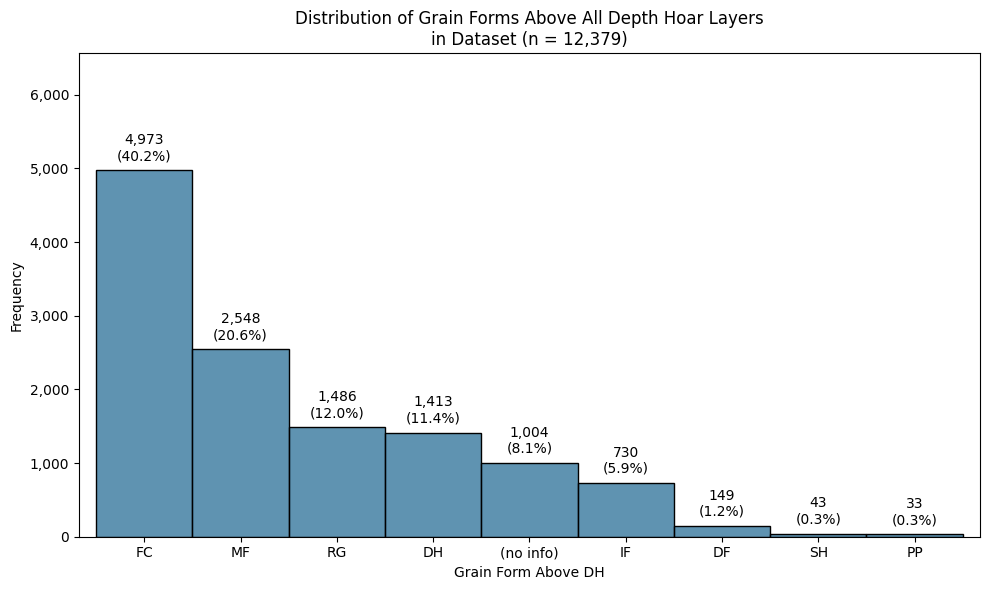

In [40]:
# Plot distribution of grain forms above all DH layers

plot_grain_form_distribution(
    all_dh_layers_df,
    'grain_form_above_dh',
    'Distribution of Grain Forms Above All Depth Hoar Layers\nin Dataset',
    'Grain Form Above DH',
    style_key='layer_above_weak_layer',
)


**For pits dug on avalanche crowns and flanks, what is the grain form of the layer of concern?**
- What is the distribution of grain forms
- How often is the grain for Depth Hoar (DH)? 

In [17]:
# Filter to pits dug on avalanche crowns and flanks
crown_and_flank_pits = []

for pit in all_pits:
    if pit.core_info.location.pit_near_avalanche_location == 'crown' or pit.core_info.location.pit_near_avalanche_location == 'flank':
        crown_and_flank_pits.append(pit)

print(f'Pits on avalanche crown or flank: {len(crown_and_flank_pits)}')

Pits on avalanche crown or flank: 1194


In [18]:
# Extract info from pits on avalanche crowns and flanks
# layer_of_concern is None when no CAAML layer is flagged; grain_form_primary can also be missing.
crown_and_flank_pits_info = []

for pit in crown_and_flank_pits:
    loc = pit.snow_profile.layer_of_concern # layer of concern
    gfp = getattr(loc, "grain_form_primary", None) if loc is not None else None # get primary grain form of LOC
    basic_code = getattr(gfp, "basic_grain_class_code", None) if gfp is not None else None # get basic grain class code of primary grain form of LOC

    crown_and_flank_pits_info.append({
        'pit_id': pit.core_info.pit_id,
        'pit_date': pit.core_info.date,
        'pit_name': pit.core_info.pit_name,
        'operation_name': pit.core_info.user.operation_name,
        'professional': pit.core_info.user.professional,
        'pit_country': pit.core_info.location.country,
        'pit_region': pit.core_info.location.region,
        'pit_near_avalanche_location': pit.core_info.location.pit_near_avalanche_location,
        'LOC_grain_form': basic_code,
        'Comments': pit.core_info.comment
    })

crown_and_flank_pits_info = pd.DataFrame(crown_and_flank_pits_info)
crown_pits = crown_and_flank_pits_info[crown_and_flank_pits_info['pit_near_avalanche_location'] == 'crown']
flank_pits = crown_and_flank_pits_info[crown_and_flank_pits_info['pit_near_avalanche_location'] == 'flank']


In [19]:
## Summary stats

# Number of pits on Crowns and Flanks
print(f'Pits on Crowns: {len(crown_pits)}')
print(f'Pits on Flanks: {len(flank_pits)}')
print(f'Crown and flank pits: {len(crown_and_flank_pits)}')


Pits on Crowns: 795
Pits on Flanks: 399
Crown and flank pits: 1194


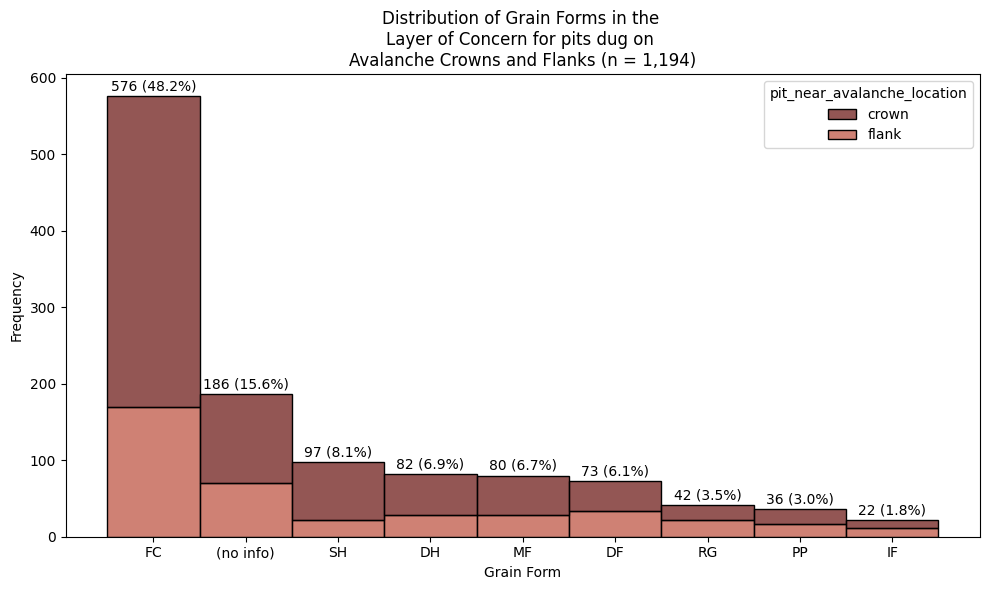

In [28]:
# Plot the frequency of grain forms, stacked by crown/flank
plot_grain_form_distribution(
    crown_and_flank_pits_info,
    'LOC_grain_form',
    'Distribution of Grain Forms in the \nLayer of Concern for pits dug on \nAvalanche Crowns and Flanks',
    'Grain Form',
    hue='pit_near_avalanche_location',
    style_key='weak_layer',
)

In [24]:
# Filter to pits where the layer of concern is depth hoar
crown_and_flank_pits_dh = []

for pit in crown_and_flank_pits:
    loc = pit.snow_profile.layer_of_concern # layer of concern
    gfp = getattr(loc, "grain_form_primary", None) if loc is not None else None # get primary grain form of LOC
    if gfp and gfp.basic_grain_class_code == 'DH':
        crown_and_flank_pits_dh.append(pit)

print(f'Pits with DH LOC: {len(crown_and_flank_pits_dh)}')


Pits with DH LOC: 82


In [22]:
# Extract grain form of layer above layer of concern

grain_form_above_dh = []

for pit in crown_and_flank_pits_dh:

    # Pit info
    pit_id = pit.core_info.pit_id
    pit_near_avalanche_location = pit.core_info.location.pit_near_avalanche_location

    # Get index of layer of concern
    loc_idx = None
    for i, layer in enumerate(pit.snow_profile.layers):
        if layer.layer_of_concern:
            loc_idx = i # index of layer of concern
            break
    if loc_idx is None or loc_idx == 0:
        grain_form_above_dh[pit.core_info.pit_id] = None
        continue

    above = pit.snow_profile.layers[loc_idx - 1] # layer above LOC
    gfp = getattr(above, "grain_form_primary", None) # grain form of layer above LOC

    # Record pit and grain form of layer above LOC
    info = {
        'pit_id': pit_id,
        'pit_near_avalanche_location': pit_near_avalanche_location,
        'grain_form_above_loc': gfp.basic_grain_class_code if gfp is not None else None
    }
    grain_form_above_dh.append(info)


grain_form_above_dh_df = pd.DataFrame(grain_form_above_dh)

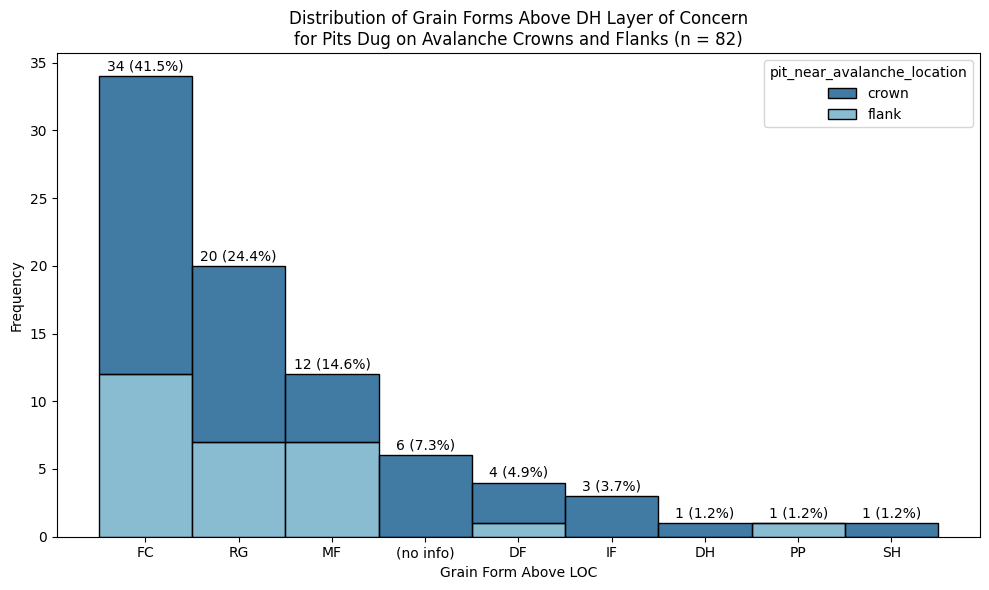

In [23]:
# Plot the frequency of grain forms above DH LOC, stacked by crown/flank
plot_grain_form_distribution(
    grain_form_above_dh_df,
    'grain_form_above_loc',
    'Distribution of Grain Forms Above DH Layer of Concern\nfor Pits Dug on Avalanche Crowns and Flanks',
    'Grain Form Above LOC',
    hue='pit_near_avalanche_location',
    style_key='layer_above_weak_layer',
)

### ECT: Grain Form of Layer Above the Layer of Failure for ECTP results

- For all ECTs where the LOC is depth hoar, and that propagate completely across the column (ECTPs), what crystal type is the layer immediately above the LOC?

In [25]:
ECTP_results = []

for pit in all_pits:
    layers = pit.snow_profile.layers
    for ECT in pit.stability_tests.ECT:
        # Check if the ECT is an ECTP
        ECTP = False

        if hasattr(ECT, "propagation") and ECT.propagation:
            ECTP = True
        elif hasattr(ECT, "test_score") and ECT.test_score and "ECTP" in str(ECT.test_score):
            ECTP = True

        if not ECTP:
            continue # If the ECT is not an ECTP, skip

        # Get failure depth
        failure_depth = ECT.depth_top[0] if ECT.depth_top is not None and len(ECT.depth_top) else None

        # Initialize matching boolean
        layer_matched = False # Whether the failure depth was matched to a snow profile layer

        if failure_depth is not None:
            # Iterate through the snow profile layers to find the layer that contains the failure depth
            for i, layer in enumerate(layers):
                depth_top = layer.depth_top[0] if layer.depth_top is not None and len(layer.depth_top) else None
                layer_thickness = layer.thickness[0] if layer.thickness is not None and len(layer.thickness) else None
                depth_bottom = depth_top + layer_thickness

                if depth_top <= failure_depth < depth_bottom: # If the failure depth is within the layer
                    layer_matched = True
                    failure_layer = layer
                    failure_layer_idx = i
                    break

        # Grain forms only when a layer matched and it is not the top snow layer.
        if not layer_matched or failure_layer_idx == 0: # If the failure depth was not matched to a layer or if it is the top snow layer
            grain_form_failure_layer = None
            grain_form_layer_above_failure_layer = None
        else: # If the failure depth was matched to a layer and it is not the top snow layer
            grain_form_failure_layer = getattr(failure_layer, "grain_form_primary", None) if failure_layer is not None else None
            layer_above_failure_layer = layers[failure_layer_idx - 1]
            grain_form_layer_above_failure_layer = getattr(layer_above_failure_layer, "grain_form_primary", None) if layer_above_failure_layer is not None else None

        ECTP_result_info = {
            'pit_id': pit.core_info.pit_id,
            'ECTP_test_score': ECT.test_score,
            'layer_matched': layer_matched,
            'matched_layer_idx': failure_layer_idx,
            'ECTP_num_taps': ECT.num_taps,
            'grain_form_failure_layer': getattr(grain_form_failure_layer, 'basic_grain_class_code', None) if grain_form_failure_layer is not None else None,
            'grain_form_layer_above_failure_layer': getattr(grain_form_layer_above_failure_layer, 'basic_grain_class_code', None) if grain_form_layer_above_failure_layer is not None else None,
        }

        ECTP_results.append(ECTP_result_info)

ECTP_results_df = pd.DataFrame(ECTP_results)


In [26]:
total_ectp_results = len(ECTP_results_df)
total_matched_results = len(ECTP_results_df[ECTP_results_df['layer_matched'] == True])
matched_on_top_layer = ECTP_results_df[
    ECTP_results_df["layer_matched"] & (ECTP_results_df["matched_layer_idx"] == 0)
]
total_for_analysis = total_matched_results - len(matched_on_top_layer)

print(f'Total ECTP results: {total_ectp_results}')
print(f'Total matched results: {total_matched_results}')
print(f'Pits matched on top layer: {len(matched_on_top_layer)}')
print("--------------------------------")
print(f'Total for analysis: {total_for_analysis}')


Total ECTP results: 15256
Total matched results: 14973
Pits matched on top layer: 197
--------------------------------
Total for analysis: 14776


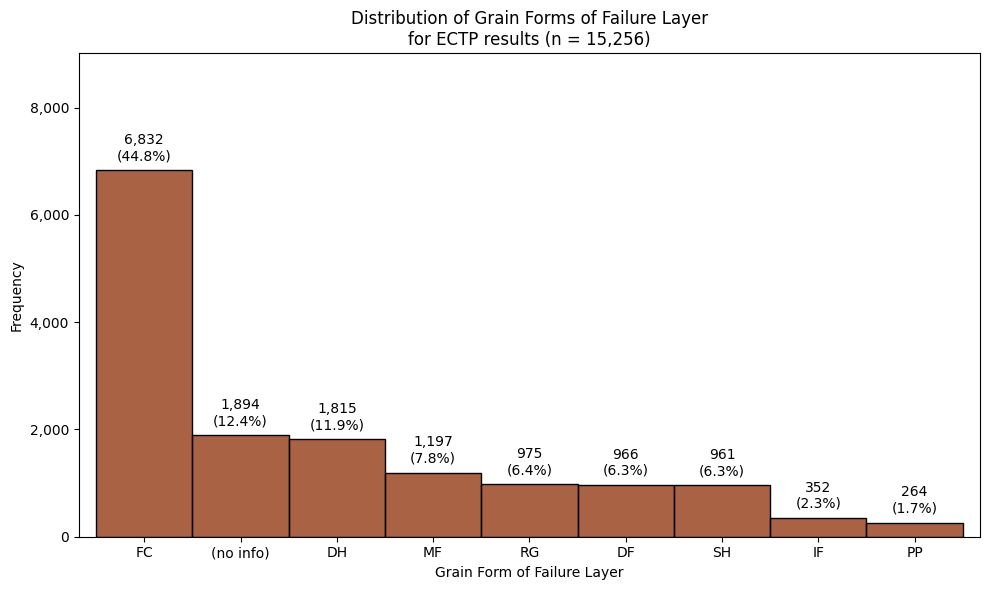

In [29]:
## Plot distribution of grain form of failure layer

plot_grain_form_distribution(
    ECTP_results_df,
    'grain_form_failure_layer',
    'Distribution of Grain Forms of Failure Layer\nfor ECTP results',
    'Grain Form of Failure Layer',
    style_key='weak_layer',
)


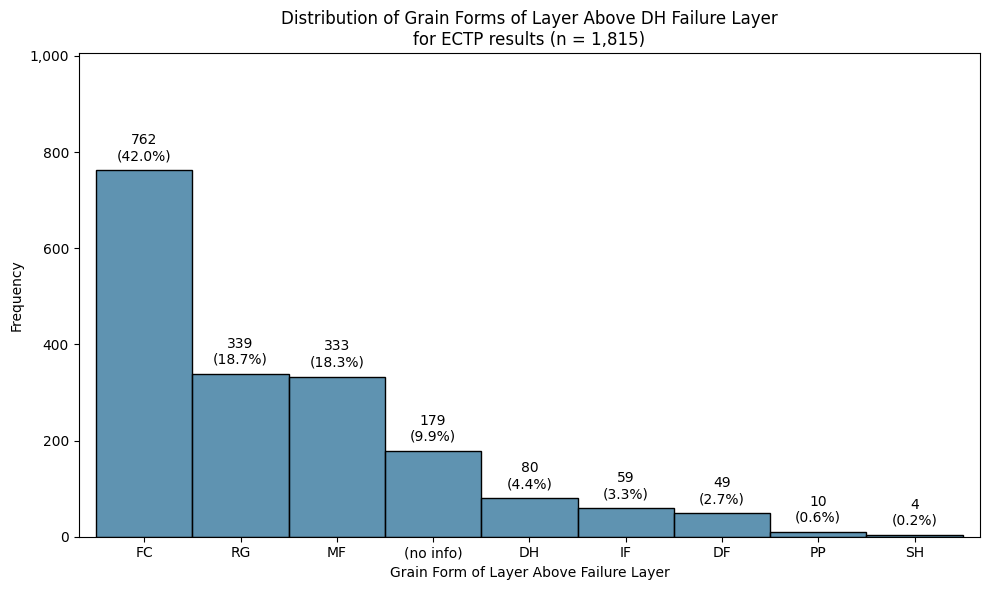

In [30]:
## Plot distribution of grain form of layer above failure layer where the failure layer is depth hoar

# Filter to ECTP results where the failure layer is depth hoar
ectp_results_dh = ECTP_results_df[ECTP_results_df['grain_form_failure_layer'] == 'DH']

# Plot distribution of grain form of layer above failure layer

plot_grain_form_distribution(
    ectp_results_dh,
    'grain_form_layer_above_failure_layer',
    'Distribution of Grain Forms of Layer Above DH Failure Layer\nfor ECTP results',
    'Grain Form of Layer Above Failure Layer',
    style_key='layer_above_weak_layer',
)

The trend in this plot is quite similar to that for the crown/flank as well as the entire data set of layers. That is, ~40% of the time facets are directly above the depth hoar.

### PST:

- For all PSTs where the LOC is depth hoar, and that propagate to END with a cut length less than 30 cm, what crystal type is the layer immediately above the LOC? 

In [31]:
PST_results = []

for pit in all_pits:
    layers = pit.snow_profile.layers
    for PST in pit.stability_tests.PST:

        match_condition = False

        # Get cut depth
        cut_depth = getattr(PST, "depth_top", None)
        cut_depth_val = cut_depth[0] if cut_depth is not None and len(cut_depth) else None

        # Get cut length
        cut_length = getattr(PST, "cut_length", None)
        cut_length_val = cut_length[0] if cut_length is not None and len(cut_length) else None

        # Get fracture propagation
        fracture_prop = getattr(PST, "fracture_prop", None)

        if fracture_prop == "End" and cut_length_val < 30: # If the test propogates to END with a cut length less than 30 cm
            match_condition = True

        if not match_condition:
            continue

        # Match to layer in snow profile

        # Initialize matching boolean
        layer_matched = False # Whether the failure depth was matched to a snow profile layer
        failure_layer_idx = None

        if cut_depth_val is not None:
            # Iterate through the snow profile layers to find the layer that contains the failure depth
            for i, layer in enumerate(layers):
                depth_top = layer.depth_top[0] if layer.depth_top is not None and len(layer.depth_top) else None
                layer_thickness = layer.thickness[0] if layer.thickness is not None and len(layer.thickness) else None
                depth_bottom = depth_top + layer_thickness

                if depth_top <= cut_depth_val < depth_bottom: # If the cut depth is within the layer
                    layer_matched = True
                    failure_layer = layer
                    failure_layer_idx = i
                    break

        # Grain forms only when a layer matched and it is not the top snow layer.
        if not layer_matched or failure_layer_idx == 0: # If the failure depth was not matched to a layer or if it is the top snow layer
            grain_form_cut_layer = None
            grain_form_layer_above_cut_layer = None
        else: # If the failure depth was matched to a layer and it is not the top snow layer
            grain_form_cut_layer = getattr(failure_layer, "grain_form_primary", None) if failure_layer is not None else None
            layer_above_cut_layer = layers[failure_layer_idx - 1]
            grain_form_layer_above_cut_layer = getattr(layer_above_cut_layer, "grain_form_primary", None) if layer_above_cut_layer is not None else None

        PST_result_info = {
            'pit_id': pit.core_info.pit_id,
            'cut_depth': cut_depth_val,
            'cut_length': cut_length_val,
            'fracture_prop': fracture_prop,
            'layer_matched': layer_matched,
            'matched_layer_idx': failure_layer_idx,
            'grain_form_cut_layer': getattr(grain_form_cut_layer, 'basic_grain_class_code', None) if grain_form_cut_layer is not None else None,
            'grain_form_layer_above_cut_layer': getattr(grain_form_layer_above_cut_layer, 'basic_grain_class_code', None) if grain_form_layer_above_cut_layer is not None else None,
        }

        PST_results.append(PST_result_info)

PST_results_df = pd.DataFrame(PST_results)


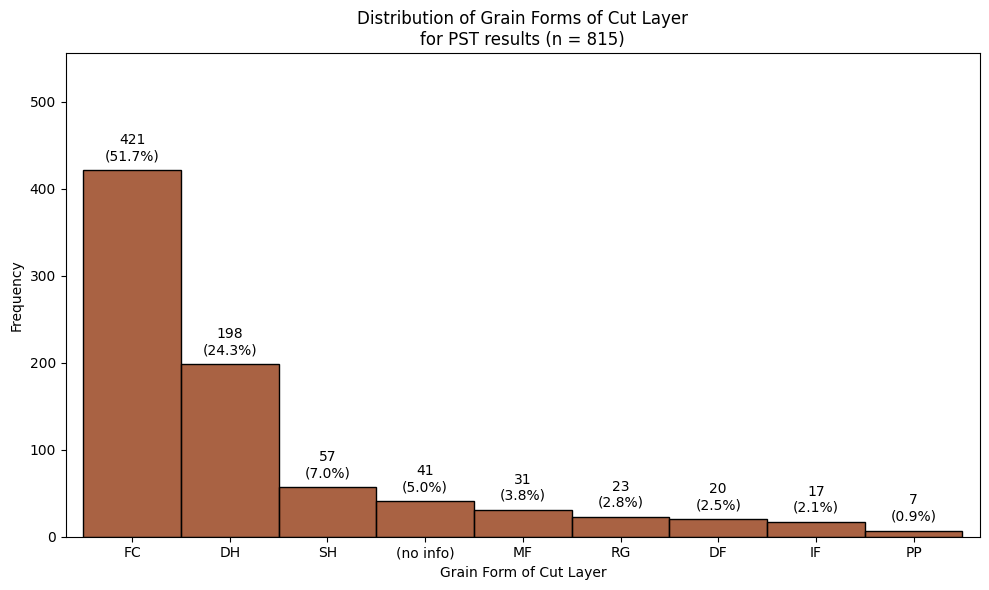

In [33]:
# Plot distribution of grain forms of cut layer

plot_grain_form_distribution(
    PST_results_df,
    'grain_form_cut_layer',
    'Distribution of Grain Forms of Cut Layer\nfor PST results',
    'Grain Form of Cut Layer',
    style_key='weak_layer',
)

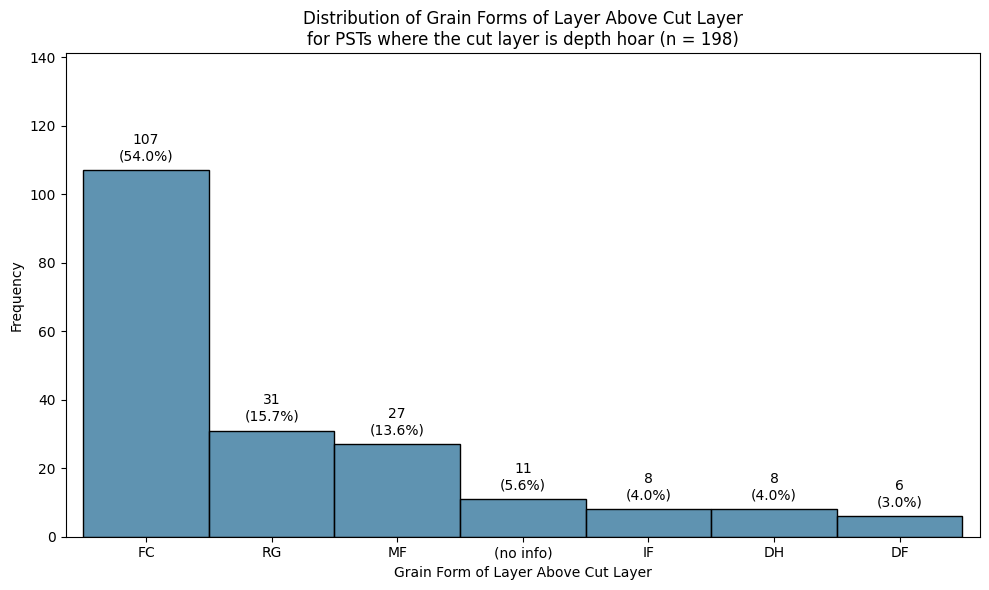

In [34]:
# Filter to PSTs where the cut layer is depth hoar
pst_results_dh = PST_results_df[PST_results_df['grain_form_cut_layer'] == 'DH']

# Plot distribution of grain forms of layer above cut layer

plot_grain_form_distribution(
    pst_results_dh,
    'grain_form_layer_above_cut_layer',
    'Distribution of Grain Forms of Layer Above Cut Layer\nfor PSTs where the cut layer is depth hoar',
    'Grain Form of Layer Above Cut Layer',
    style_key='layer_above_weak_layer',
)



Even higher prevalence of faceted crystals above depth hoar in this case (54%)

What is the height above the bottom of the depth hoar layer for ECTP results?

In [41]:
# Calculate height above bottom of DH layer for ECTP results

height_above_dh_bottom = []

for pit in all_pits:
    layers = pit.snow_profile.layers
    for ECT in pit.stability_tests.ECT:
        # Check if the ECT is an ECTP
        ECTP = False
        if hasattr(ECT, "propagation") and ECT.propagation:
            ECTP = True
        elif hasattr(ECT, "test_score") and ECT.test_score and "ECTP" in str(ECT.test_score):
            ECTP = True
        
        if not ECTP:
            continue
        
        # Get failure depth
        failure_depth = ECT.depth_top[0] if ECT.depth_top is not None and len(ECT.depth_top) else None
        
        if failure_depth is None:
            continue
        
        # Find the layer containing the failure depth
        failure_layer_idx = None
        for i, layer in enumerate(layers):
            depth_top = layer.depth_top[0] if layer.depth_top is not None and len(layer.depth_top) else None
            layer_thickness = layer.thickness[0] if layer.thickness is not None and len(layer.thickness) else None
            
            if depth_top is None or layer_thickness is None:
                continue
            
            depth_bottom = depth_top + layer_thickness
            
            if depth_top <= failure_depth < depth_bottom:
                failure_layer_idx = i
                failure_layer = layer
                break
        
        if failure_layer_idx is None:
            continue
        
        # Check if failure layer is depth hoar
        grain_form_failure = getattr(failure_layer, "grain_form_primary", None)
        if grain_form_failure is None or grain_form_failure.basic_grain_class_code != 'DH':
            continue
        
        # Calculate height above bottom of DH layer
        depth_top = failure_layer.depth_top[0]
        layer_thickness = failure_layer.thickness[0]
        depth_bottom = depth_top + layer_thickness
        height_above_bottom = depth_bottom - failure_depth
        
        height_above_dh_bottom.append({
            'pit_id': pit.core_info.pit_id,
            'failure_depth': failure_depth,
            'dh_depth_top': depth_top,
            'dh_depth_bottom': depth_bottom,
            'dh_thickness': layer_thickness,
            'height_above_bottom': height_above_bottom,
        })

height_above_dh_df = pd.DataFrame(height_above_dh_bottom)

if len(height_above_dh_df) > 0:
    print(f'ECTPs on DH layers: {len(height_above_dh_df)}')
    print(f'\nHeight above bottom of DH layer statistics:')
    print(height_above_dh_df['height_above_bottom'].describe())
    print(f'\nMin: {height_above_dh_df["height_above_bottom"].min():.1f} cm')
    print(f'Max: {height_above_dh_df["height_above_bottom"].max():.1f} cm')
    print(f'Mean: {height_above_dh_df["height_above_bottom"].mean():.1f} cm')
    print(f'Median: {height_above_dh_df["height_above_bottom"].median():.1f} cm')
else:
    print('No ECTP results on DH layers found')


ECTPs on DH layers: 1818

Height above bottom of DH layer statistics:
count    1818.000000
mean       20.445242
std        14.318327
min         0.050000
25%        10.000000
50%        18.000000
75%        29.000000
max        87.000000
Name: height_above_bottom, dtype: float64

Min: 0.0 cm
Max: 87.0 cm
Mean: 20.4 cm
Median: 18.0 cm


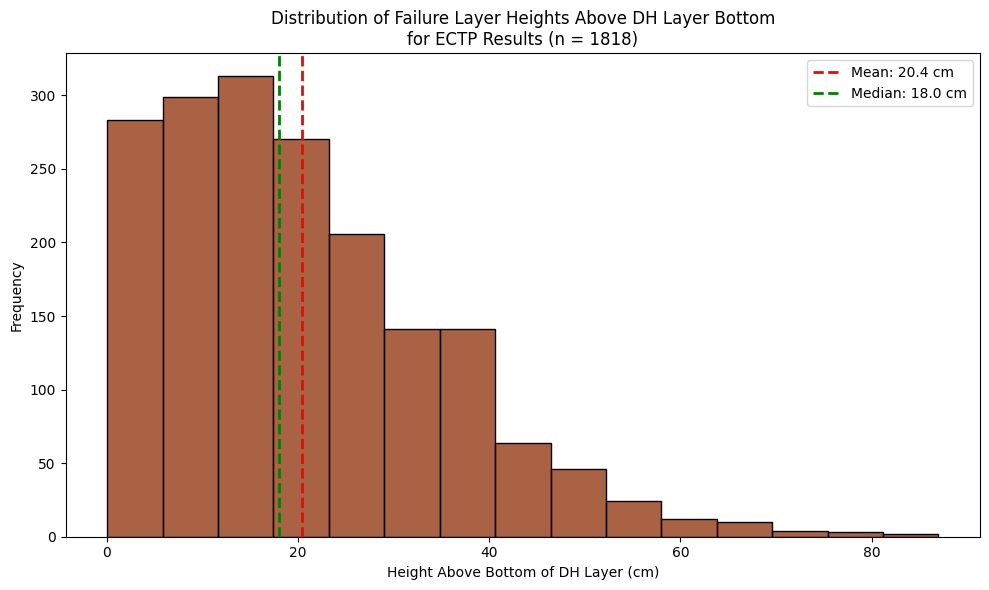

In [44]:
# Visualize distribution of heights above DH bottom for ECTP results

if len(height_above_dh_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    sns.histplot(data=height_above_dh_df, x='height_above_bottom', ax=ax, bins=15, color='#8C2D04')
    
    ax.set_xlabel('Height Above Bottom of DH Layer (cm)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of Failure Layer Heights Above DH Layer Bottom\nfor ECTP Results (n = {len(height_above_dh_df)})')
    ax.axvline(height_above_dh_df['height_above_bottom'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {height_above_dh_df["height_above_bottom"].mean():.1f} cm')
    ax.axvline(height_above_dh_df['height_above_bottom'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {height_above_dh_df["height_above_bottom"].median():.1f} cm')
    ax.legend()
    
    fig.tight_layout()
    plt.show()


In [45]:
# Analyze distribution of DH layer thicknesses for ECTP results

if len(height_above_dh_df) > 0:
    print(f'ECTPs on DH layers: {len(height_above_dh_df)}')
    print(f'\nDepth Hoar Layer Thickness Distribution:')
    print(height_above_dh_df['dh_thickness'].describe())
    print(f'\nMin: {height_above_dh_df["dh_thickness"].min():.1f} cm')
    print(f'Max: {height_above_dh_df["dh_thickness"].max():.1f} cm')
    print(f'Mean: {height_above_dh_df["dh_thickness"].mean():.1f} cm')
    print(f'Median: {height_above_dh_df["dh_thickness"].median():.1f} cm')
    print(f'Std Dev: {height_above_dh_df["dh_thickness"].std():.1f} cm')
else:
    print('No ECTP results on DH layers found')


ECTPs on DH layers: 1818

Depth Hoar Layer Thickness Distribution:
count    1818.000000
mean       23.176705
std        14.703069
min         0.050000
25%        13.000000
50%        20.000000
75%        30.000000
max       105.000000
Name: dh_thickness, dtype: float64

Min: 0.1 cm
Max: 105.0 cm
Mean: 23.2 cm
Median: 20.0 cm
Std Dev: 14.7 cm


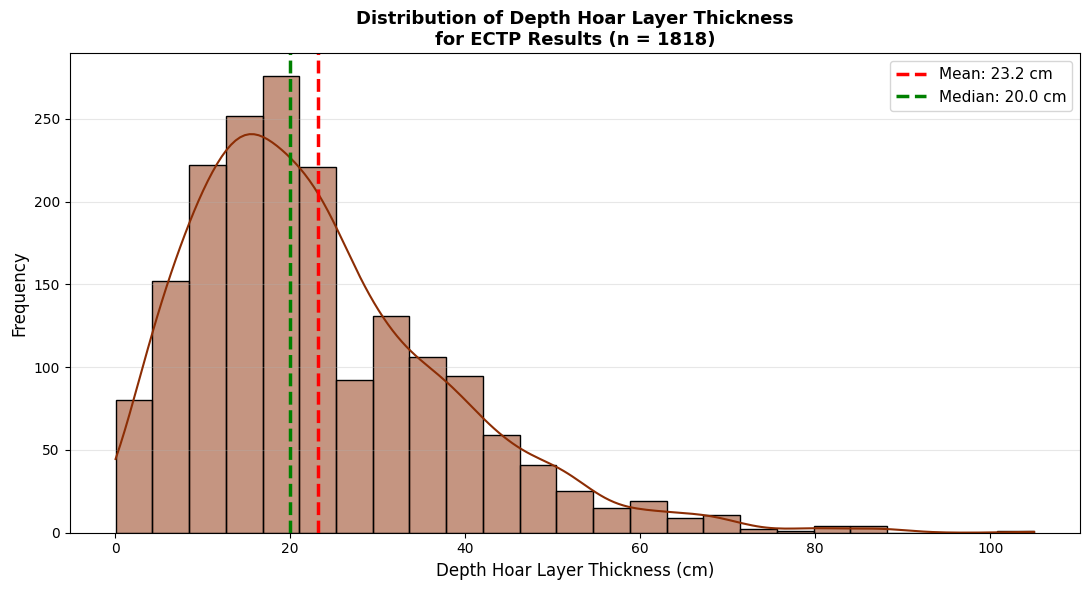

In [46]:
# Simple histogram of DH layer thickness for ECTP results

if len(height_above_dh_df) > 0:
    fig, ax = plt.subplots(figsize=(11, 6))
    
    sns.histplot(data=height_above_dh_df, x='dh_thickness', ax=ax, bins=25, color='#8C2D04', kde=True)
    
    ax.set_xlabel('Depth Hoar Layer Thickness (cm)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'Distribution of Depth Hoar Layer Thickness\nfor ECTP Results (n = {len(height_above_dh_df)})', fontsize=13, fontweight='bold')
    ax.axvline(height_above_dh_df['dh_thickness'].mean(), color='red', linestyle='--', linewidth=2.5, label=f'Mean: {height_above_dh_df["dh_thickness"].mean():.1f} cm')
    ax.axvline(height_above_dh_df['dh_thickness'].median(), color='green', linestyle='--', linewidth=2.5, label=f'Median: {height_above_dh_df["dh_thickness"].median():.1f} cm')
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    
    fig.tight_layout()
    plt.show()


Distance from Top of DH Layer to Failure:
count    1818.000000
mean        2.731463
std         6.053881
min         0.000000
25%         0.000000
50%         0.000000
75%         2.000000
max        63.000000
Name: distance_from_top, dtype: float64

Min: 0.0 cm
Max: 63.0 cm
Mean: 2.7 cm
Median: 0.0 cm


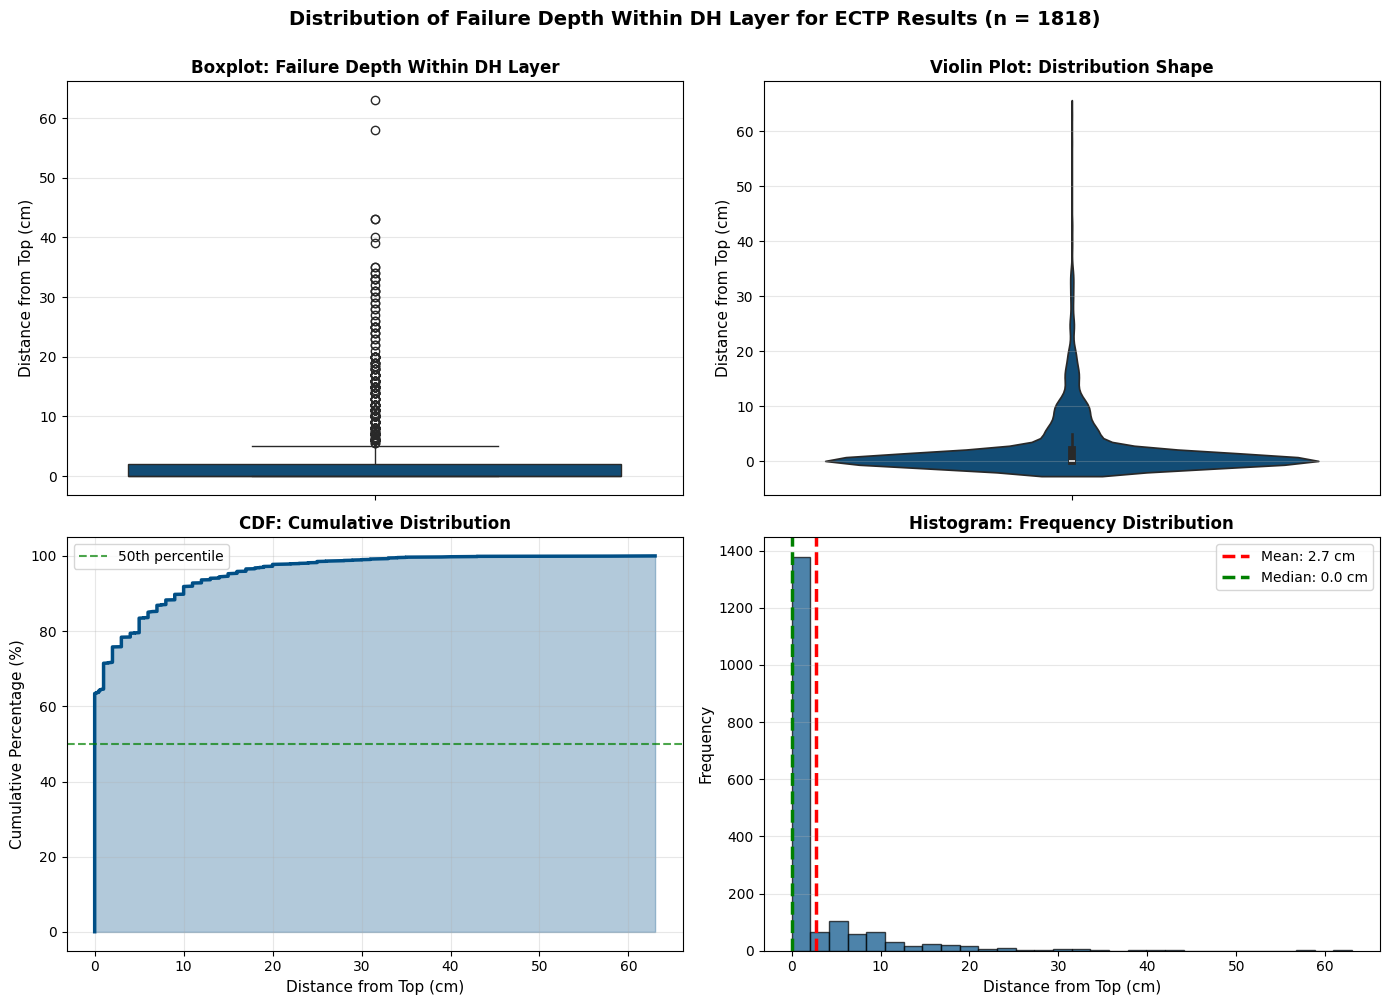

In [52]:
# Calculate and visualize distance from top of DH layer to failure point

if len(height_above_dh_df) > 0:
    # Calculate distance from top of DH layer to failure
    height_above_dh_df['distance_from_top'] = height_above_dh_df['failure_depth'] - height_above_dh_df['dh_depth_top']
    
    print(f'Distance from Top of DH Layer to Failure:')
    print(height_above_dh_df['distance_from_top'].describe())
    print(f'\nMin: {height_above_dh_df["distance_from_top"].min():.1f} cm')
    print(f'Max: {height_above_dh_df["distance_from_top"].max():.1f} cm')
    print(f'Mean: {height_above_dh_df["distance_from_top"].mean():.1f} cm')
    print(f'Median: {height_above_dh_df["distance_from_top"].median():.1f} cm')
    
    # Create multiple visualizations for skewed distribution
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Boxplot - shows quartiles and outliers clearly
    sns.boxplot(data=height_above_dh_df, y='distance_from_top', ax=axes[0, 0], color='#014F86')
    axes[0, 0].set_ylabel('Distance from Top (cm)', fontsize=11)
    axes[0, 0].set_title('Boxplot: Failure Depth Within DH Layer', fontsize=12, fontweight='bold')
    axes[0, 0].grid(axis='y', alpha=0.3)
    
    # 2. Violin plot - shows full distribution shape
    sns.violinplot(data=height_above_dh_df, y='distance_from_top', ax=axes[0, 1], color='#014F86')
    axes[0, 1].set_ylabel('Distance from Top (cm)', fontsize=11)
    axes[0, 1].set_title('Violin Plot: Distribution Shape', fontsize=12, fontweight='bold')
    axes[0, 1].grid(axis='y', alpha=0.3)
    
    # 3. Cumulative distribution function (CDF)
    sorted_data = np.sort(height_above_dh_df['distance_from_top'])
    cumulative = np.arange(1, len(sorted_data) + 1) / len(sorted_data) * 100
    axes[1, 0].plot(sorted_data, cumulative, color='#014F86', linewidth=2.5)
    axes[1, 0].fill_between(sorted_data, cumulative, alpha=0.3, color='#014F86')
    axes[1, 0].set_xlabel('Distance from Top (cm)', fontsize=11)
    axes[1, 0].set_ylabel('Cumulative Percentage (%)', fontsize=11)
    axes[1, 0].set_title('CDF: Cumulative Distribution', fontsize=12, fontweight='bold')
    axes[1, 0].grid(alpha=0.3)
    axes[1, 0].axhline(50, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='50th percentile')
    axes[1, 0].legend(fontsize=10)
    
    # 4. Histogram with better binning for the skewed data
    axes[1, 1].hist(height_above_dh_df['distance_from_top'], bins=30, color='#014F86', edgecolor='black', alpha=0.7)
    axes[1, 1].axvline(height_above_dh_df['distance_from_top'].mean(), color='red', linestyle='--', linewidth=2.5, label=f'Mean: {height_above_dh_df["distance_from_top"].mean():.1f} cm')
    axes[1, 1].axvline(height_above_dh_df['distance_from_top'].median(), color='green', linestyle='--', linewidth=2.5, label=f'Median: {height_above_dh_df["distance_from_top"].median():.1f} cm')
    axes[1, 1].set_xlabel('Distance from Top (cm)', fontsize=11)
    axes[1, 1].set_ylabel('Frequency', fontsize=11)
    axes[1, 1].set_title('Histogram: Frequency Distribution', fontsize=12, fontweight='bold')
    axes[1, 1].legend(fontsize=10)
    axes[1, 1].grid(axis='y', alpha=0.3)
    
    fig.suptitle(f'Distribution of Failure Depth Within DH Layer for ECTP Results (n = {len(height_above_dh_df)})', 
                 fontsize=14, fontweight='bold', y=1.00)
    fig.tight_layout()
    plt.show()


~60% of the time, users are reporting ECTP failures at the top of the depth hoar layer. This could be just how people are reporting or it could be the actual failure location. I think the CDF shows this the best.

What is the height above the bottom of the depth hoar layer for crown/flank results?

In [19]:
# Calculate height above bottom of DH layer for crown/flank results

height_above_dh_bottom_crown_flank = []

for pit in crown_and_flank_pits_dh:
    loc = pit.snow_profile.layer_of_concern
    
    # Get index of layer of concern
    loc_idx = None
    for i, layer in enumerate(pit.snow_profile.layers):
        if layer.layer_of_concern:
            loc_idx = i
            break
    
    if loc_idx is None:
        continue
    
    # Get DH layer info
    dh_layer = pit.snow_profile.layers[loc_idx]
    depth_top = dh_layer.depth_top[0] if dh_layer.depth_top is not None and len(dh_layer.depth_top) else None
    layer_thickness = dh_layer.thickness[0] if dh_layer.thickness is not None and len(dh_layer.thickness) else None
    
    if depth_top is None or layer_thickness is None:
        continue
    
    depth_bottom = depth_top + layer_thickness
    
    # For this analysis, we're looking at the layer itself (the entire DH layer)
    # The "height above bottom" could mean different things depending on interpretation
    # Storing the layer's vertical extent
    
    height_above_dh_bottom_crown_flank.append({
        'pit_id': pit.core_info.pit_id,
        'pit_near_avalanche_location': pit.core_info.location.pit_near_avalanche_location,
        'dh_depth_top': depth_top,
        'dh_depth_bottom': depth_bottom,
        'dh_thickness': layer_thickness,
    })

height_above_dh_crown_flank_df = pd.DataFrame(height_above_dh_bottom_crown_flank)

if len(height_above_dh_crown_flank_df) > 0:
    print(f'DH LOC in crown/flank pits: {len(height_above_dh_crown_flank_df)}')
    print(f'\nDH Layer thickness statistics:')
    print(height_above_dh_crown_flank_df['dh_thickness'].describe())
    print(f'\nBy location:')
    print(height_above_dh_crown_flank_df.groupby('pit_near_avalanche_location')['dh_thickness'].describe())
else:
    print('No crown/flank pits with DH LOC found')


DH LOC in crown/flank pits: 82

DH Layer thickness statistics:
count    82.000000
mean     22.539024
std      12.340876
min       3.000000
25%      12.250000
50%      20.000000
75%      30.000000
max      50.000000
Name: dh_thickness, dtype: float64

By location:
                             count       mean        std  min    25%   50%  \
pit_near_avalanche_location                                                  
crown                         54.0  20.133333  11.522529  3.0  10.50  19.2   
flank                         28.0  27.178571  12.742619  5.0  19.75  26.5   

                               75%   max  
pit_near_avalanche_location               
crown                        24.75  50.0  
flank                        35.00  50.0  


/var/folders/68/mw0899ms47s4fdlxb957r6pw0000gn/T/ipykernel_7980/677036624.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=height_above_dh_crown_flank_df, x='pit_near_avalanche_location', y='dh_thickness', ax=ax, palette=['#6F1D1B', '#C05746'])


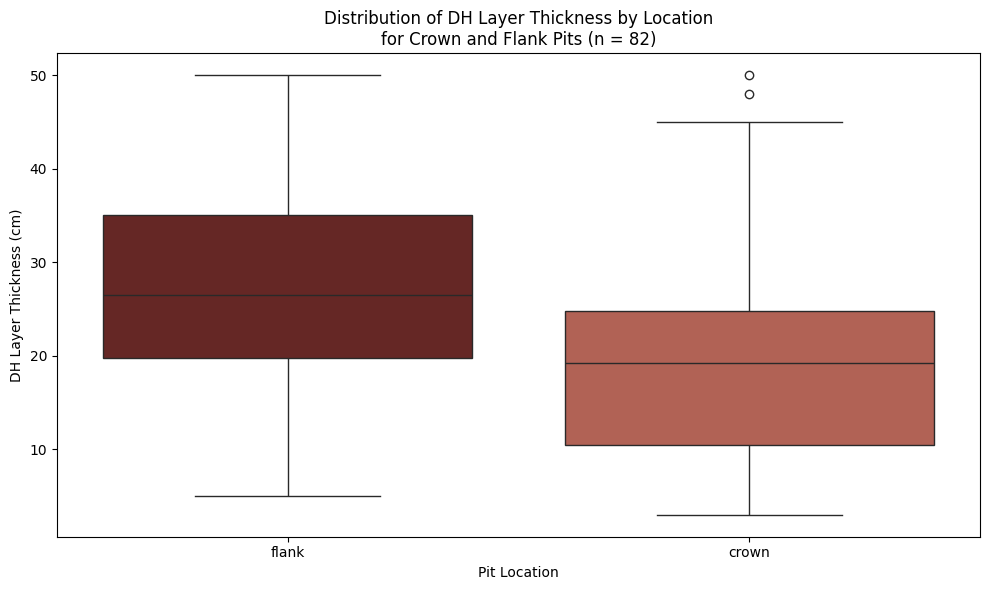

In [20]:
# Visualize DH layer thickness by crown/flank location

if len(height_above_dh_crown_flank_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    sns.boxplot(data=height_above_dh_crown_flank_df, x='pit_near_avalanche_location', y='dh_thickness', ax=ax, palette=['#6F1D1B', '#C05746'])
    
    ax.set_xlabel('Pit Location')
    ax.set_ylabel('DH Layer Thickness (cm)')
    ax.set_title(f'Distribution of DH Layer Thickness by Location\nfor Crown and Flank Pits (n = {len(height_above_dh_crown_flank_df)})')
    
    fig.tight_layout()
    plt.show()


For pits that have both ECTP and PST results, where are PST cuts occuring? Ron also asked about PST fractures starting in one layer, then "jumping" to another Snowpilot does not capture this information.

In [56]:
# Find pits with both ECTP and PST results

# First, get unique pit IDs with ECTP results
ectp_pit_ids = set(ECTP_results_df['pit_id'].unique())

# Get unique pit IDs with PST results
pst_pit_ids = set(PST_results_df['pit_id'].unique())

# Find pits that have both
pits_with_both = ectp_pit_ids.intersection(pst_pit_ids)

print(f'Pits with ECTP results: {len(ectp_pit_ids)}')
print(f'Pits with PST results: {len(pst_pit_ids)}')
print(f'Pits with BOTH ECTP and PST results: {len(pits_with_both)}')

# Filter to get ECTP and PST results for pits with both
ectp_with_pst = ECTP_results_df[ECTP_results_df['pit_id'].isin(pits_with_both)].copy()
pst_with_ectp = PST_results_df[PST_results_df['pit_id'].isin(pits_with_both)].copy()

print(f'\nECTP results in pits with both: {len(ectp_with_pst)}')
print(f'PST results in pits with both: {len(pst_with_ectp)}')

# For each pit with both tests, compare the depths
comparison_data = []

for pit_id in pits_with_both:
    ectp_tests = ectp_with_pst[ectp_with_pst['pit_id'] == pit_id]
    pst_tests = pst_with_ectp[pst_with_ectp['pit_id'] == pit_id]
    
    for ectp_idx, ectp_row in ectp_tests.iterrows():
        ectp_depth = ectp_row['matched_layer_idx'] if ectp_row['layer_matched'] else None
        ectp_failure_depth = height_above_dh_df[height_above_dh_df['pit_id'] == pit_id]['failure_depth'].values
        
        for pst_idx, pst_row in pst_tests.iterrows():
            pst_depth = pst_row['matched_layer_idx']
            pst_cut_depth = pst_row['cut_depth']
            
            comparison_data.append({
                'pit_id': pit_id,
                'ectp_layer_idx': ectp_depth,
                'pst_layer_idx': pst_depth,
                'pst_cut_depth_cm': pst_cut_depth,
                'same_layer': ectp_depth == pst_depth if ectp_depth is not None and pst_depth is not None else None,
            })

comparison_df = pd.DataFrame(comparison_data)

print(f'\n\nECTP vs PST Comparisons (within pits that have both):')
print(f'Total comparisons: {len(comparison_df)}')

if len(comparison_df) > 0:
    same_layer = comparison_df[comparison_df['same_layer'] == True]
    diff_layer = comparison_df[comparison_df['same_layer'] == False]
    
    print(f'PST and ECTP in SAME layer: {len(same_layer)} ({100*len(same_layer)/len(comparison_df):.1f}%)')
    print(f'PST and ECTP in DIFFERENT layers: {len(diff_layer)} ({100*len(diff_layer)/len(comparison_df):.1f}%)')


Pits with ECTP results: 12704
Pits with PST results: 732
Pits with BOTH ECTP and PST results: 454

ECTP results in pits with both: 597
PST results in pits with both: 511


ECTP vs PST Comparisons (within pits that have both):
Total comparisons: 703
PST and ECTP in SAME layer: 556 (79.1%)
PST and ECTP in DIFFERENT layers: 138 (19.6%)


In [57]:
# Detailed analysis of layer differences when PST and ECTP are in different layers

comparison_df['layer_difference'] = comparison_df['pst_layer_idx'] - comparison_df['ectp_layer_idx']

print('\n\nDetailed Analysis of Layer Differences:')
print('='*60)

diff_layer_df = comparison_df[comparison_df['same_layer'] == False].copy()

if len(diff_layer_df) > 0:
    print(f'\nLayer index differences (PST layer - ECTP layer):')
    print(diff_layer_df['layer_difference'].describe())
    
    print(f'\nPST cuts DEEPER than ECTP failures (positive difference):')
    deeper = diff_layer_df[diff_layer_df['layer_difference'] > 0]
    print(f'  Count: {len(deeper)} ({100*len(deeper)/len(diff_layer_df):.1f}%)')
    
    print(f'\nPST cuts SHALLOWER than ECTP failures (negative difference):')
    shallower = diff_layer_df[diff_layer_df['layer_difference'] < 0]
    print(f'  Count: {len(shallower)} ({100*len(shallower)/len(diff_layer_df):.1f}%)')
    
    print(f'\nLayer difference distribution:')
    print(diff_layer_df['layer_difference'].value_counts().sort_index())




Detailed Analysis of Layer Differences:

Layer index differences (PST layer - ECTP layer):
count    138.000000
mean       0.673913
std        3.004044
min       -8.000000
25%       -1.750000
50%        1.000000
75%        2.000000
max        7.000000
Name: layer_difference, dtype: float64

PST cuts DEEPER than ECTP failures (positive difference):
  Count: 92 (66.7%)

PST cuts SHALLOWER than ECTP failures (negative difference):
  Count: 46 (33.3%)

Layer difference distribution:
layer_difference
-8.0     2
-7.0     1
-6.0     3
-5.0     3
-4.0     4
-3.0     5
-2.0    17
-1.0    11
 1.0    25
 2.0    36
 3.0    14
 4.0     7
 5.0     5
 6.0     2
 7.0     3
Name: count, dtype: int64


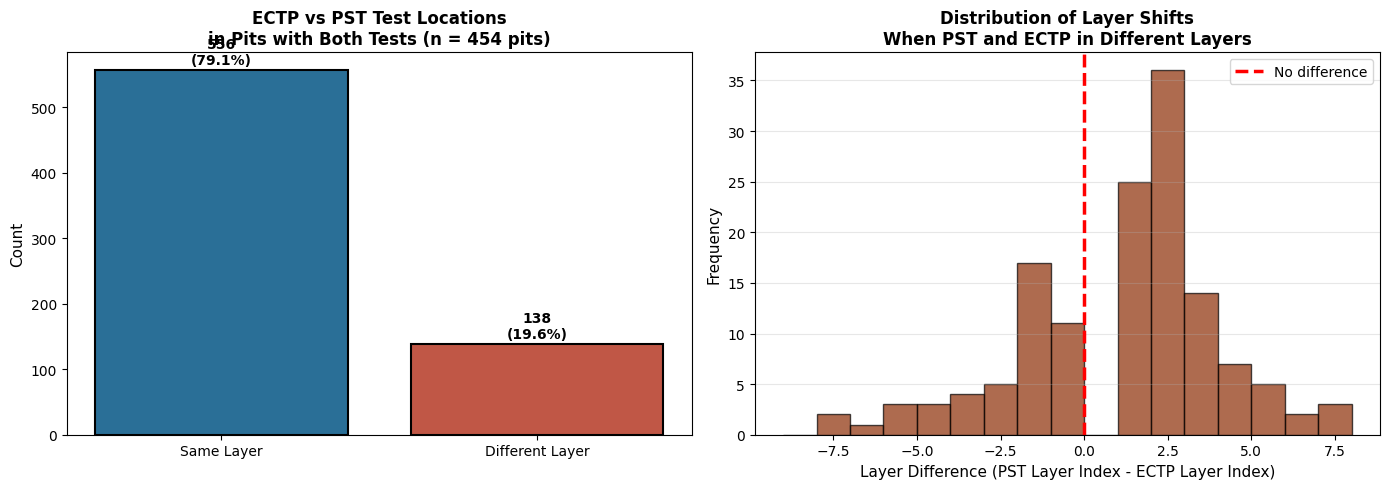

In [59]:
# Visualize PST cut locations vs ECTP failure locations

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: Same vs Different
categories = ['Same Layer', 'Different Layer']
counts = [len(same_layer), len(diff_layer)]
colors = ['#2A6F97', '#C05746']

axes[0].bar(categories, counts, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('ECTP vs PST Test Locations\nin Pits with Both Tests (n = 454 pits)', fontsize=12, fontweight='bold')
for i, (cat, count) in enumerate(zip(categories, counts)):
    pct = 100 * count / len(comparison_df)
    axes[0].text(i, count + 10, f'{count}\n({pct:.1f}%)', ha='center', fontsize=10, fontweight='bold')

# Histogram: Layer differences
if len(diff_layer_df) > 0:
    axes[1].hist(diff_layer_df['layer_difference'], bins=range(int(diff_layer_df['layer_difference'].min())-1, int(diff_layer_df['layer_difference'].max())+2), 
                 color='#8C2D04', edgecolor='black', alpha=0.7)
    axes[1].axvline(0, color='red', linestyle='--', linewidth=2.5, label='No difference')
    axes[1].set_xlabel('Layer Difference (PST Layer Index - ECTP Layer Index)', fontsize=11)
    axes[1].set_ylabel('Frequency', fontsize=11)
    axes[1].set_title('Distribution of Layer Shifts\nWhen PST and ECTP in Different Layers', fontsize=12, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### ECTP vs PST: Analysis When Failure Layer is Depth Hoar

For pits where ECTP failures occur in depth hoar layers, where are the PST cuts occurring relative to these ECTP failure points?


In [ ]:
# Filter to ECTP results where failure layer is depth hoar
ectp_pit_ids_dh = set(ECTP_results_df[ECTP_results_df['grain_form_failure_layer'] == 'DH']['pit_id'].unique())

# Get PST results for pits with DH ECTP failures
pst_pit_ids_dh = set(PST_results_df[PST_results_df['pit_id'].isin(ectp_pit_ids_dh)]['pit_id'].unique())

# Intersection: pits that have both ECTP with DH failure AND PST results
pits_with_both_dh = ectp_pit_ids_dh.intersection(pst_pit_ids_dh)

print(f'ECTP results with DH failure: {len(ectp_pit_ids_dh)}')
print(f'PST results in those pits: {len(pst_pit_ids_dh)}')
print(f'Pits with BOTH ECTP DH failure AND PST results: {len(pits_with_both_dh)}')

# Create comparison data for DH ECTP failures only
ectp_dh = ECTP_results_df[(ECTP_results_df['grain_form_failure_layer'] == 'DH') & 
                          (ECTP_results_df['pit_id'].isin(pits_with_both_dh))]
pst_with_ectp_dh = PST_results_df[PST_results_df['pit_id'].isin(pits_with_both_dh)]

comparison_data_dh = []

for pit_id in pits_with_both_dh:
    ectp_tests = ectp_dh[ectp_dh['pit_id'] == pit_id]
    pst_tests = pst_with_ectp_dh[pst_with_ectp_dh['pit_id'] == pit_id]
    
    for ectp_idx, ectp_row in ectp_tests.iterrows():
        ectp_depth = ectp_row['matched_layer_idx'] if ectp_row['layer_matched'] else None
        
        for pst_idx, pst_row in pst_tests.iterrows():
            pst_depth = pst_row['matched_layer_idx']
            pst_cut_depth = pst_row['cut_depth']
            
            comparison_data_dh.append({
                'pit_id': pit_id,
                'ectp_layer_idx': ectp_depth,
                'pst_layer_idx': pst_depth,
                'pst_cut_depth_cm': pst_cut_depth,
                'same_layer': ectp_depth == pst_depth if ectp_depth is not None and pst_depth is not None else None,
            })

comparison_df_dh = pd.DataFrame(comparison_data_dh)

# Calculate layer_difference column
comparison_df_dh['layer_difference'] = comparison_df_dh['pst_layer_idx'] - comparison_df_dh['ectp_layer_idx']

print(f'\n\nECTP (DH failure) vs PST Comparisons:')
print(f'Total comparisons: {len(comparison_df_dh)}')

if len(comparison_df_dh) > 0:
    # Filter AFTER adding the layer_difference column
    same_layer_dh = comparison_df_dh[comparison_df_dh['same_layer'] == True]
    diff_layer_dh = comparison_df_dh[comparison_df_dh['same_layer'] == False]
    
    print(f'PST and ECTP in SAME layer: {len(same_layer_dh)} ({100*len(same_layer_dh)/len(comparison_df_dh):.1f}%)')
    print(f'PST and ECTP in DIFFERENT layers: {len(diff_layer_dh)} ({100*len(diff_layer_dh)/len(comparison_df_dh):.1f}%)')
    
    if len(diff_layer_dh) > 0:
        print(f'\nLayer index differences (PST layer - ECTP layer):')
        print(diff_layer_dh['layer_difference'].describe())
        
        print(f'\nPST cuts DEEPER than ECTP failures (positive difference):')
        deeper_dh = diff_layer_dh[diff_layer_dh['layer_difference'] > 0]
        print(f'  Count: {len(deeper_dh)} ({100*len(deeper_dh)/len(diff_layer_dh):.1f}%)')
        
        print(f'\nPST cuts SHALLOWER than ECTP failures (negative difference):')
        shallower_dh = diff_layer_dh[diff_layer_dh['layer_difference'] < 0]
        print(f'  Count: {len(shallower_dh)} ({100*len(shallower_dh)/len(diff_layer_dh):.1f}%)')
        
        print(f'\nLayer difference distribution:')
        print(diff_layer_dh['layer_difference'].value_counts().sort_index())


ECTP results with DH failure: 1611
PST results in those pits: 101
Pits with BOTH ECTP DH failure AND PST results: 101


ECTP (DH failure) vs PST Comparisons:
Total comparisons: 181
PST and ECTP in SAME layer: 161 (89.0%)
PST and ECTP in DIFFERENT layers: 20 (11.0%)

Layer index differences (PST layer - ECTP layer):
count    20.000000
mean     -2.100000
std       1.518309
min      -5.000000
25%      -2.250000
50%      -2.000000
75%      -1.000000
max       1.000000
Name: layer_difference, dtype: float64

PST cuts DEEPER than ECTP failures (positive difference):
  Count: 1 (5.0%)

PST cuts SHALLOWER than ECTP failures (negative difference):
  Count: 19 (95.0%)

Layer difference distribution:
layer_difference
-5.0    3
-3.0    2
-2.0    8
-1.0    6
 1.0    1
Name: count, dtype: int64


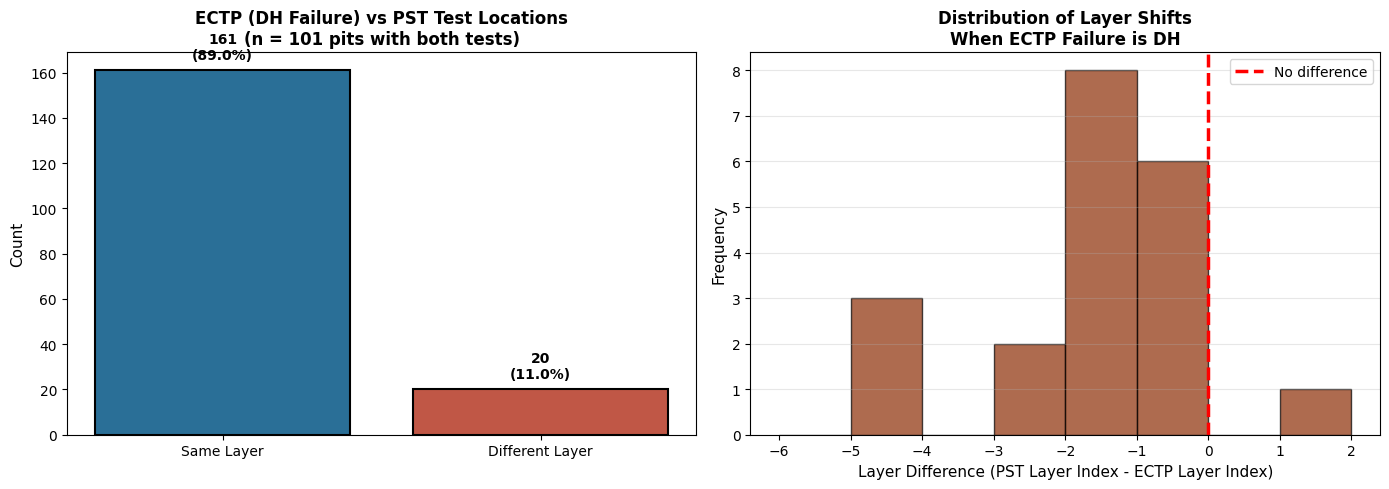

In [63]:
# Visualize PST vs ECTP when ECTP failure is in depth hoar

if len(comparison_df_dh) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart: Same vs Different
    categories = ['Same Layer', 'Different Layer']
    counts = [len(same_layer_dh), len(diff_layer_dh)]
    colors = ['#2A6F97', '#C05746']
    
    axes[0].bar(categories, counts, color=colors, edgecolor='black', linewidth=1.5)
    axes[0].set_ylabel('Count', fontsize=11)
    axes[0].set_title('ECTP (DH Failure) vs PST Test Locations\n(n = {} pits with both tests)'.format(len(pits_with_both_dh)), 
                      fontsize=12, fontweight='bold')
    for i, (cat, count) in enumerate(zip(categories, counts)):
        pct = 100 * count / len(comparison_df_dh)
        axes[0].text(i, count + 5, f'{count}\n({pct:.1f}%)', ha='center', fontsize=10, fontweight='bold')
    
    # Histogram: Layer differences
    if len(diff_layer_dh) > 0:
        axes[1].hist(diff_layer_dh['layer_difference'], 
                    bins=range(int(diff_layer_dh['layer_difference'].min())-1, int(diff_layer_dh['layer_difference'].max())+2), 
                    color='#8C2D04', edgecolor='black', alpha=0.7)
        axes[1].axvline(0, color='red', linestyle='--', linewidth=2.5, label='No difference')
        axes[1].set_xlabel('Layer Difference (PST Layer Index - ECTP Layer Index)', fontsize=11)
        axes[1].set_ylabel('Frequency', fontsize=11)
        axes[1].set_title('Distribution of Layer Shifts\nWhen ECTP Failure is DH', fontsize=12, fontweight='bold')
        axes[1].legend(fontsize=10)
        axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

